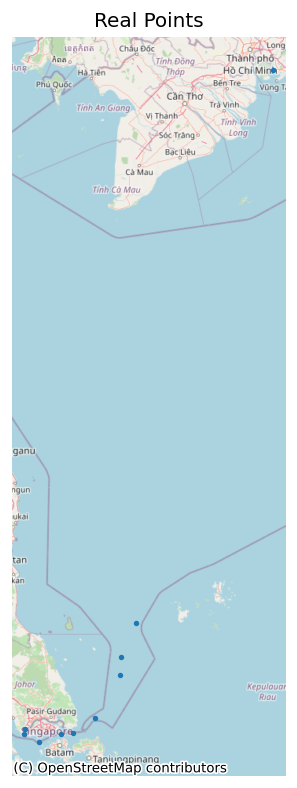

In [ ]:
import pandas as pd # handles data
import geopandas as gpd # understands locations
import matplotlib.pyplot as plt # to plot
import contextily as ctx # enables bg map

df = pd.read_csv("umm_salal.csv") # reads csv

# geodataframe
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs="EPSG:4326" 
)
gdf_web = gdf.to_crs(epsg=3857) # converts to web mercator

fig, ax = plt.subplots(figsize=(8, 8), dpi=120)

gdf_web.plot(ax=ax, markersize=5) # plot points
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik) # adds map 

ax.set_title("Real Points") 
ax.set_axis_off()

plt.show()

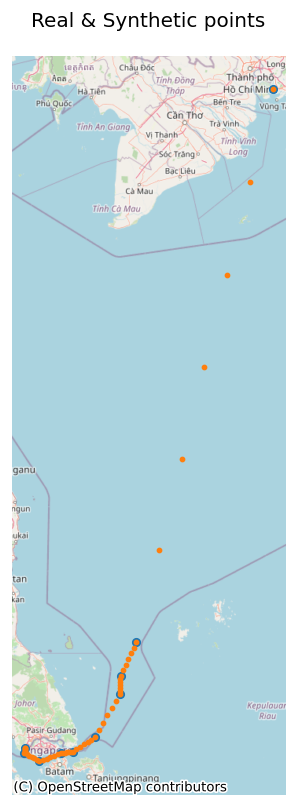

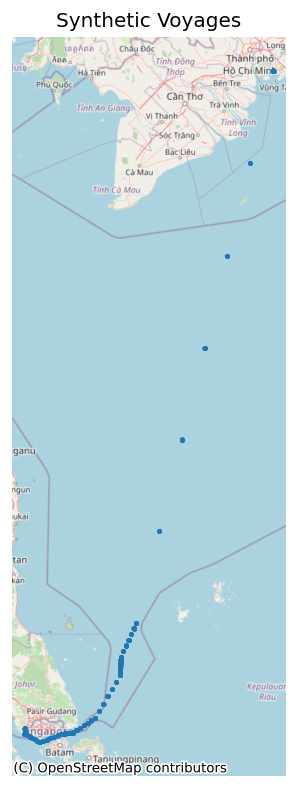

In [11]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

df = pd.read_csv("umm_salal.csv")

synthetic_rows = [] # empty list to store
n_between = 5 # creates synthetic points

for i in range(len(df) - 1): # loop through real points 
    lat1, lon1 = df.loc[i, ['Latitude', 'Longitude']]
    lat2, lon2 = df.loc[i+1, ['Latitude', 'Longitude']]
    synthetic_rows.append([lat1, lon1]) # saves first real point

    for j in range(1, n_between + 1): # loop to create 5 new points 
        alpha = j / (n_between + 1) # for equal time intervals

        lat_new = lat1 + alpha * (lat2 - lat1) # linear interpolation 
        lon_new = lon1 + alpha * (lon2 - lon1)

        lat_new += np.random.normal(0, 0.0005) # small randomness
        lon_new += np.random.normal(0, 0.0005)
        synthetic_rows.append([lat_new, lon_new])

synthetic_rows.append([df.loc[len(df)-1, 'Latitude'],df.loc[len(df)-1, 'Longitude']])

df_synth = pd.DataFrame(synthetic_rows, columns=['Latitude', 'Longitude'])
df_synth.to_csv("Synthetic_Points.csv", index=False)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs="EPSG:4326"
)

# converts to geodataframe
gdf_synth = gpd.GeoDataFrame(
    df_synth,
    geometry=gpd.points_from_xy(df_synth['Longitude'], df_synth['Latitude']),
    crs="EPSG:4326"
)
gdf_web = gdf.to_crs(epsg=3857)
gdf_synth_web = gdf_synth.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8), dpi=120)

gdf_web.plot(ax=ax, markersize=20)
gdf_synth_web.plot(ax=ax, markersize=6)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Real & Synthetic points")
ax.set_axis_off()
plt.show()

# Creates 10 synthetic voyages
num_voyages = 10
noise_std_voyage = 0.001 # seperates each voyage

all_voyages = []

# concates real + synthetic
base_df = pd.concat([
    df[['Latitude', 'Longitude']],
    df_synth[['Latitude', 'Longitude']]
]).reset_index(drop=True) # cleans rows

for v in range(1, num_voyages + 1): # loop to create 10 voyages
    df_v = base_df.copy() # fresh copy
    # adds deviation
    df_v['Latitude']  = df_v['Latitude']  + np.random.normal(0, noise_std_voyage, size=len(df_v))
    df_v['Longitude'] = df_v['Longitude'] + np.random.normal(0, noise_std_voyage, size=len(df_v))

    df_v['voyage_id'] = v # to append voyages
    all_voyages.append(df_v)

df_10_voyages = pd.concat(all_voyages).reset_index(drop=True)
df_10_voyages.to_csv("Synthetic_Voyages.csv", index=False)

gdf_10 = gpd.GeoDataFrame(
    df_10_voyages,
    geometry=gpd.points_from_xy(df_10_voyages['Longitude'], df_10_voyages['Latitude']),
    crs="EPSG:4326"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8), dpi=120)
gdf_10.plot(ax=ax, markersize=3)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Synthetic Voyages")
ax.set_axis_off()
plt.show()